
# レジームスイッチングと多変量正規分布を用いた市場動態のモデリング (v3)

このノートブックでは、S&P 500 (SPX) と米国10年国債利回り (DGS10) のデータに対し、**隠れマルコフモデル的なアプローチ（GMMによるレジーム分類＋推移確率行列）**と**レジーム別の多変量正規分布（静的相関）**を組み合わせた分析パイプラインを解説します。

## 全体のパイプライン概要
1. **特徴量エンジニアリング**: SPXとDGS10の標準偏差、相関係数を計算し、市場の「状態」を捉えやすくする。（※平均値は使用しません）
2. **GMMによるクラスタリング**: 特徴量を元に、市場を4つの状態（レジーム）に分類する。
3. **推移確率行列の計算**: 状態間の遷移確率を経験的に計算する。
4. **状態ごとのARIMAモデリング（期待値の計算）**: 各状態でARIMAXモデルを推定し、条件付き期待値を算出する。
5. **レジーム別共分散行列の計算とマルコフ連鎖によるシミュレーション生成**: 状態遷移確率行列から状態遷移数列を確率的に生成し、それに対応する予測値（期待値）と共分散からシミュレーションを行う。


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
# from statsmodels.tsa.arima.model import ARIMA  # Removed: VARMAX used exclusively
from statsmodels.tsa.statespace.varmax import VARMAX
import warnings
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')



## 1. データの読み込みと特徴量エンジニアリング

### 理論
金融市場は常に同じ法則で動いているわけではなく、「ボラティリティが高い時期」「金利と株価が逆相関になる時期」など、マクロ的な環境（レジーム）が変化します。
この環境変化を捉えるため、単純な価格の変動だけでなく、「20日（約1ヶ月）の標準偏差、および相関」という**ローリング特徴量**を作成します。
さらに、市場の方向性（トレンド）を捉えるため、「20日間の変化分」を特徴量として加えます。
- SPXの20日変化分：20日間の累積リターン（積）
- DGS10の20日変化分：20日間の変動幅（和）

これにより、瞬間的なノイズではなく、一定期間のボラティリティの強さ、資産間の関係性、そして相場のトレンドを総合的に元に状態を分類できるようになります。


In [2]:
df = pd.read_csv('/home/u00118/train_sp500_us10y.csv')
if 'Unnamed: 0' in df.columns:
    df['Date'] = pd.to_datetime(df['Unnamed: 0'])
    df.set_index('Date', inplace=True)
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ローリング特徴量の作成 (20日 = 約1ヶ月)
window = 20
df['sp500_roll_std'] = df['sp500'].rolling(window=window).std()
df['DGS10_roll_std'] = df['DGS10'].rolling(window=window).std()
df['corr'] = df['sp500'].rolling(window=window).corr(df['DGS10'])

# 20日間の変化分（トレンド）の追加
df['sp500_roll_ret20'] = (1 + df['sp500']).rolling(window=window).apply(np.prod, raw=True) - 1
df['DGS10_roll_sum20'] = df['DGS10'].rolling(window=window).sum()

# もう一方の変数の過去1日分のデータ（外生変数用）
df['DGS10_lag1'] = df['DGS10'].shift(1)
df['sp500_lag1'] = df['sp500'].shift(1)

# 欠損値の削除
df_features = df.dropna().copy()
print(f"有効なデータ件数: {len(df_features)}件")

# GMMクラスタリング用の特徴量（5次元）
features = df_features[['sp500_roll_std', 'DGS10_roll_std', 'corr', 'sp500_roll_ret20', 'DGS10_roll_sum20']]


有効なデータ件数: 14715件



## 2. GMMを用いたN個の状態（レジーム）へのクラスタリング

### 理論と計算手法（数式）
GMM（Gaussian Mixture Model: 混合ガウスモデル）は、データが複数の正規分布の集まり（混合分布）から生成されていると仮定し、それぞれのデータがどの分布から生成されたか（どの状態に属するか）を確率的に推定する手法です。ここでは変数を設定し、市場を任意の数（`N_REGIMES`）のレジームに分類できるようにしています。

**1. モデルの確率密度関数**
特徴量ベクトル $x$ が与えられたときの全体の確率分布 $P(x)$ は、各レジームの正規分布の線形結合として表されます。
$$
P(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

**2. EMアルゴリズムによるパラメータ推定**
未知のパラメータ $\theta = \{\pi_k, \mu_k, \Sigma_k\}$ は、尤度が最大になるように **EMアルゴリズム** によって反復計算で推定されます。

**3. レジームの判定**
EMアルゴリズムが収束した後、各時点 $t$ における市場のレジーム $S_t$ は、最も事後確率が高い分布として割り当てられます（ハードクラスタリング）。
$$
S_t = \arg\max_k \gamma(z_{tk})
$$
これにより、「平穏な相場」「荒れ相場」などが自動的にグループ化されます。


In [3]:
# レジームの数を指定（ここを変更するだけで全体に反映されます）
N_REGIMES = 14

gmm = GaussianMixture(n_components=N_REGIMES, random_state=42, n_init=10)
df_features['Regime'] = gmm.fit_predict(features)

print("各レジームのデータ件数:")
print(df_features['Regime'].value_counts().sort_index())

# 状態の可視化 (Plotly)
fig = go.Figure()

# S&P 500 Return
fig.add_trace(go.Scatter(
    x=df_features.index, y=df_features['sp500'],
    mode='lines',
    line=dict(color='black', width=1),
    opacity=0.3,
    name='S&P 500 Return'
))

# 各レジームの散布図
colors = px.colors.qualitative.Plotly
for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    fig.add_trace(go.Scatter(
        x=df_features.index[mask], y=df_features['sp500'][mask],
        mode='markers',
        marker=dict(color=colors[i % len(colors)], size=4),
        name=f'Regime {i}'
    ))

fig.update_layout(
    title=f'S&P 500 Returns by GMM Clustered Regime (N={N_REGIMES})',
    xaxis_title='Date',
    yaxis_title='Return',
    height=500,
    legend_title='Legend (Click to toggle)'
)
fig.show()


各レジームのデータ件数:
Regime
0      931
1      450
2     2123
3      493
4     1653
5      654
6      807
7     2958
8      678
9      260
10     149
11     776
12    1620
13    1163
Name: count, dtype: int64



## 3. 状態遷移確率行列の計算

### 理論
市場のレジームは、ランダムに切り替わるわけではありません。「荒れ相場」の次の日は「荒れ相場」になりやすいといった**持続性（マルコフ性）**があります。
推移確率行列（Transition Matrix）は、「現在の状態が $i$ のとき、次の日に状態が $j$ になる確率 $P(S_{t+1}=j | S_t=i)$」を行列にしたものです。
対角成分（[0,0]や[1,1]など）が大きいほど、その状態が持続しやすいことを意味します。


In [4]:
transition_matrix = np.zeros((N_REGIMES, N_REGIMES))
regimes = df_features['Regime'].values
for t in range(1, len(regimes)):
    from_state = regimes[t-1]
    to_state = regimes[t]
    transition_matrix[from_state, to_state] += 1

# 行ごとに正規化して確率に変換
transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)

print("【推移確率行列 (Transition Matrix)】")
for i in range(N_REGIMES):
    probs_str = ", ".join([f"[{j}]:{transition_matrix[i,j]:.3f}" for j in range(N_REGIMES)])
    print(f"状態 {i} からの遷移確率: {probs_str}")


【推移確率行列 (Transition Matrix)】
状態 0 からの遷移確率: [0]:0.823, [1]:0.000, [2]:0.032, [3]:0.013, [4]:0.039, [5]:0.002, [6]:0.033, [7]:0.013, [8]:0.027, [9]:0.003, [10]:0.000, [11]:0.000, [12]:0.000, [13]:0.015
状態 1 からの遷移確率: [0]:0.000, [1]:0.896, [2]:0.007, [3]:0.000, [4]:0.000, [5]:0.031, [6]:0.002, [7]:0.000, [8]:0.000, [9]:0.002, [10]:0.002, [11]:0.027, [12]:0.027, [13]:0.007
状態 2 からの遷移確率: [0]:0.008, [1]:0.005, [2]:0.826, [3]:0.003, [4]:0.001, [5]:0.008, [6]:0.022, [7]:0.039, [8]:0.000, [9]:0.000, [10]:0.000, [11]:0.007, [12]:0.043, [13]:0.039
状態 3 からの遷移確率: [0]:0.034, [1]:0.000, [2]:0.008, [3]:0.858, [4]:0.000, [5]:0.000, [6]:0.037, [7]:0.000, [8]:0.041, [9]:0.002, [10]:0.010, [11]:0.008, [12]:0.000, [13]:0.002
状態 4 からの遷移確率: [0]:0.024, [1]:0.000, [2]:0.001, [3]:0.000, [4]:0.901, [5]:0.000, [6]:0.010, [7]:0.041, [8]:0.023, [9]:0.000, [10]:0.000, [11]:0.000, [12]:0.000, [13]:0.000
状態 5 からの遷移確率: [0]:0.005, [1]:0.014, [2]:0.040, [3]:0.000, [4]:0.000, [5]:0.817, [6]:0.000, [7]:0.000, [8]:0.000, [9]


## 4. 状態ごとのVARIMAモデリング（期待値の計算）

### 内部でのカルマンフィルタ（状態空間モデル）の役割と数式表現

本コードで使用している `statsmodels` の `VARIMA` クラスは、内部的にモデルを**線形状態空間モデル（Linear State-Space Model）**として定式化し、**カルマンフィルタ（Kalman Filter）**を用いて最尤推定および期待値の算出を行っています。
# ARIMA modeling removed; VARIMA handles predictions for both series

（$\phi$ はAR係数、$\theta$ はMA係数）

**カルマンフィルタによる予測と更新のアルゴリズム**
与えられたデータから尤度を計算し、最適な予測を得るために、以下の漸化式を各時点 $t$ で反復します。
* **予測ステップ (Prediction)**:
  * 状態の事前推定: $a_{t|t-1} = T a_{t-1|t-1}$
  * 誤差共分散の事前推定: $P_{t|t-1} = T P_{t-1|t-1} T^\top + R Q R^\top$
* **更新ステップ (Update)**:
  * 観測の予測誤差 (イノベーション): $v_t = y_t - Z a_{t|t-1} - x_t^\top \beta$
  * 予測誤差の分散: $F_t = Z P_{t|t-1} Z^\top + H$
  * カルマンゲイン (修正の重み): $K_t = P_{t|t-1} Z^\top F_t^{-1}$
  * 状態の事後推定: $a_{t|t} = a_{t|t-1} + K_t v_t$
  * 誤差共分散の事後推定: $P_{t|t} = P_{t|t-1} - K_t Z P_{t|t-1}$

**欠損データ（非連続なレジーム）に対するカルマンフィルタの挙動**
本分析ではレジームごとにデータを分割しているため、対象外のレジームの期間は `NaN`（欠損値）となります。カルマンフィルタはこのようなトビトビのデータに対して以下のように振る舞います。
* **データが欠損している時点 $t$**:
  観測値 $y_t$ が存在しないため、更新ステップ（Update）はスキップされます（事実上カルマンゲイン $K_t = 0$）。
  しかし、予測ステップ（Prediction）は継続して行われるため、事後推定値は更新されず（$a_{t|t} = a_{t|t-1}$）、次の時点への予測状態は以下のように前進し続けます。
  $$ a_{t+1|t} = T a_{t|t} = T a_{t|t-1} $$
  $$ P_{t+1|t} = T P_{t|t} T^\top + R Q R^\top = T P_{t|t-1} T^\top + R Q R^\top $$
  これにより、カレンダー通りの正しい時間関係（ラグ）を維持したまま、見えない期間の内部状態（ARMAプロセスの見えないノイズ）を推定し続けることができます。

`model.fit()` は、このカルマンフィルタから得られる予測誤差 $v_t$ とその分散 $F_t$ を用いて対数尤度を計算し、尤度が最大になるようにパラメータ（$\phi, \theta, \beta$ 等）を最適化しています。


In [5]:
# モデルの保存用辞書
models_varmax = {}
df_features['sp500_pred'] = np.nan
df_features['DGS10_pred'] = np.nan

for i in range(N_REGIMES):
    print(f"\n--- レジーム {i} のモデルフィッティング ---")
    mask = df_features['Regime'] == i
    
    # VARIMA (VARMA) モデル with order (p=2, q=1)
    # Endogenous variables: sp500 and DGS10 (exogは使用しません)
    endog = df_features[['sp500', 'DGS10']].copy()
    endog[~mask] = np.nan
    try:
        model = VARMAX(endog=endog, order=(2, 1))
        res = model.fit(disp=False)
        models_varmax[i] = res
        preds = res.predict()
        df_features.loc[mask, 'sp500_pred'] = preds.loc[mask, 'sp500']
        df_features.loc[mask, 'DGS10_pred'] = preds.loc[mask, 'DGS10']
        print(f"【VARIMA 推定パラメータ】\n{res.params}")
    except Exception as e:
        print(e)

# 残差（予測誤差）を全期間連続データとして計算
df_features['resid_sp500'] = df_features['sp500'] - df_features['sp500_pred']
df_features['resid_dgs'] = df_features['DGS10'] - df_features['DGS10_pred']
df_features['resid_sp500'].fillna(0, inplace=True)
df_features['resid_dgs'].fillna(0, inplace=True)



--- レジーム 0 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000076
intercept.DGS10        -0.000027
L1.sp500.sp500          0.668181
L1.DGS10.sp500          0.004590
L2.sp500.sp500          0.298810
L2.DGS10.sp500          0.007666
L1.sp500.DGS10         -0.025263
L1.DGS10.DGS10          0.641857
L2.sp500.DGS10         -0.011787
L2.DGS10.DGS10          0.308192
L1.e(sp500).sp500      -0.418678
L1.e(DGS10).sp500      -0.029247
L1.e(sp500).DGS10      -0.146484
L1.e(DGS10).DGS10      -0.617967
sqrt.var.sp500          0.012489
sqrt.cov.sp500.DGS10    0.005875
sqrt.var.DGS10         -0.060018
dtype: float64

--- レジーム 1 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000521
intercept.DGS10        -0.001486
L1.sp500.sp500          0.578781
L1.DGS10.sp500         -0.044904
L2.sp500.sp500          0.533930
L2.DGS10.sp500          0.072102
L1.sp500.DGS10         -0.813474
L1.DGS10.DGS10          0.743003
L2.sp500.DGS10         -0.690130
L2.DGS10.DGS10          0.065462
L1.e(sp500).sp500      -0.160278
L1.e(DGS10).sp500       0.046171
L1.e(sp500).DGS10      -0.378596
L1.e(DGS10).DGS10      -0.522646
sqrt.var.sp500          0.012143
sqrt.cov.sp500.DGS10   -0.059264
sqrt.var.DGS10          0.085195
dtype: float64

--- レジーム 2 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500         0.000138
intercept.DGS10         0.000721
L1.sp500.sp500          0.525100
L1.DGS10.sp500         -0.003476
L2.sp500.sp500          0.345792
L2.DGS10.sp500         -0.010226
L1.sp500.DGS10          0.244479
L1.DGS10.DGS10          0.575937
L2.sp500.DGS10         -0.327771
L2.DGS10.DGS10          0.307662
L1.e(sp500).sp500      -0.807493
L1.e(DGS10).sp500       0.012810
L1.e(sp500).DGS10      -0.023120
L1.e(DGS10).DGS10      -0.833302
sqrt.var.sp500          0.007740
sqrt.cov.sp500.DGS10   -0.013958
sqrt.var.DGS10          0.056852
dtype: float64

--- レジーム 3 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000356
intercept.DGS10        -0.001314
L1.sp500.sp500          0.623636
L1.DGS10.sp500         -0.107533
L2.sp500.sp500          0.406306
L2.DGS10.sp500          0.049892
L1.sp500.DGS10          0.580310
L1.DGS10.DGS10          0.999069
L2.sp500.DGS10         -0.221484
L2.DGS10.DGS10         -0.111051
L1.e(sp500).sp500      -0.694838
L1.e(DGS10).sp500       0.132873
L1.e(sp500).DGS10      -0.200094
L1.e(DGS10).DGS10      -0.717433
sqrt.var.sp500          0.019749
sqrt.cov.sp500.DGS10    0.031796
sqrt.var.DGS10          0.085441
dtype: float64

--- レジーム 4 のモデルフィッティング ---


...

【VARIMA 推定パラメータ】
intercept.sp500         0.000532
intercept.DGS10        -0.001505
L1.sp500.sp500          0.381817
L1.DGS10.sp500          0.056129
L2.sp500.sp500          0.639269
L2.DGS10.sp500         -0.038603
L1.sp500.DGS10          0.970577
L1.DGS10.DGS10          0.794727
L2.sp500.DGS10         -1.072631
L2.DGS10.DGS10          0.154250
L1.e(sp500).sp500      -0.874569
L1.e(DGS10).sp500      -0.045400
L1.e(sp500).DGS10      -0.002721
L1.e(DGS10).DGS10      -0.833211
sqrt.var.sp500          0.047233
sqrt.cov.sp500.DGS10    0.033666
sqrt.var.DGS10         -0.125857
dtype: float64

--- レジーム 11 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000093
intercept.DGS10         0.000893
L1.sp500.sp500          0.569318
L1.DGS10.sp500         -0.008509
L2.sp500.sp500          0.347580
L2.DGS10.sp500          0.029657
L1.sp500.DGS10         -0.350636
L1.DGS10.DGS10          0.825147
L2.sp500.DGS10         -2.014266
L2.DGS10.DGS10         -0.014299
L1.e(sp500).sp500      -0.472212
L1.e(DGS10).sp500      -0.003671
L1.e(sp500).DGS10       0.346754
L1.e(DGS10).DGS10      -0.707325
sqrt.var.sp500          0.008977
sqrt.cov.sp500.DGS10   -0.043207
sqrt.var.DGS10          0.153423
dtype: float64

--- レジーム 12 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000026
intercept.DGS10         0.000420
L1.sp500.sp500          0.603196
L1.DGS10.sp500         -0.001600
L2.sp500.sp500          0.341979
L2.DGS10.sp500          0.000602
L1.sp500.DGS10         -0.190962
L1.DGS10.DGS10          0.559494
L2.sp500.DGS10          0.153951
L2.DGS10.DGS10          0.379848
L1.e(sp500).sp500      -0.317393
L1.e(DGS10).sp500      -0.024950
L1.e(sp500).DGS10      -0.117850
L1.e(DGS10).DGS10      -0.367784
sqrt.var.sp500         -0.008025
sqrt.cov.sp500.DGS10    0.033536
sqrt.var.DGS10          0.052306
dtype: float64

--- レジーム 13 のモデルフィッティング ---


【VARIMA 推定パラメータ】
intercept.sp500        -0.000133
intercept.DGS10         0.000235
L1.sp500.sp500          0.551751
L1.DGS10.sp500          0.000740
L2.sp500.sp500          0.393365
L2.DGS10.sp500         -0.003409
L1.sp500.DGS10         -0.152716
L1.DGS10.DGS10          0.589589
L2.sp500.DGS10          0.243144
L2.DGS10.DGS10          0.370715
L1.e(sp500).sp500      -0.683417
L1.e(DGS10).sp500      -0.004946
L1.e(sp500).DGS10      -0.004414
L1.e(DGS10).DGS10      -0.666469
sqrt.var.sp500          0.008443
sqrt.cov.sp500.DGS10   -0.010746
sqrt.var.DGS10          0.049193
dtype: float64


Date
1966-01-28    0.018513
1966-01-31    0.038893
1966-02-01   -0.005113
1966-02-02   -0.009014
1966-02-03   -0.007601
                ...   
2025-09-26    0.014539
2025-09-29   -0.053482
2025-09-30   -0.008775
2025-10-01   -0.033355
2025-10-02   -0.025518
Name: resid_dgs, Length: 14715, dtype: float64


### レジームごとの予測誤差（残差）の分布比較
各レジームにおけるARIMAモデルの予測誤差（実際の値 - 予測値）の分布を、**度数分布多角形（Frequency Polygon）**で比較します。
横軸に予測誤差、縦軸に密度（Density）を配置することで、レジームのばらつき（ボラティリティの大きさ）や分布の偏りを、凡例のクリックで直感的に表示・非表示を切り替えながら比較できます。


In [6]:
# レジームごとの分布可視化 (Plotly)
fig = make_subplots(rows=1, cols=2, subplot_titles=("SPX Prediction Error Distribution", "DGS10 Prediction Error Distribution"))
colors = px.colors.qualitative.Plotly

# ビンの幅を全体で統一して計算
spx_min, spx_max = df_features['resid_sp500'].min(), df_features['resid_sp500'].max()
dgs_min, dgs_max = df_features['resid_dgs'].min(), df_features['resid_dgs'].max()
spx_bins = np.linspace(spx_min, spx_max, 50)
dgs_bins = np.linspace(dgs_min, dgs_max, 50)
spx_bin_centers = (spx_bins[:-1] + spx_bins[1:]) / 2
dgs_bin_centers = (dgs_bins[:-1] + dgs_bins[1:]) / 2

for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    data_spx = df_features.loc[mask, 'resid_sp500'].dropna()
    data_dgs = df_features.loc[mask, 'resid_dgs'].dropna()
    
    # SPX Frequency Polygon
    if len(data_spx) > 1:
        hist_spx, _ = np.histogram(data_spx, bins=spx_bins, density=True)
        fig.add_trace(go.Scatter(
            x=spx_bin_centers, y=hist_spx, mode='lines',
            name=f'Regime {i}', line=dict(color=colors[i % len(colors)], width=2),
            legendgroup=f'Regime {i}', showlegend=True
        ), row=1, col=1)
    
    # DGS10 Frequency Polygon
    if len(data_dgs) > 1:
        hist_dgs, _ = np.histogram(data_dgs, bins=dgs_bins, density=True)
        fig.add_trace(go.Scatter(
            x=dgs_bin_centers, y=hist_dgs, mode='lines',
            name=f'Regime {i}', line=dict(color=colors[i % len(colors)], width=2),
            legendgroup=f'Regime {i}', showlegend=False
        ), row=1, col=2)

fig.update_layout(
    height=500,
    legend_title='Legend (Click to toggle)'
)
fig.update_xaxes(title_text="Prediction Error", row=1, col=1)
fig.update_yaxes(title_text="Density", row=1, col=1)
fig.update_xaxes(title_text="Prediction Error", row=1, col=2)
fig.update_yaxes(title_text="Density", row=1, col=2)
fig.show()


## 5. レジーム別共分散行列の計算とマルコフ連鎖によるシミュレーション生成

### 理論: マルコフ連鎖による状態系列の生成とシミュレーション

実データのレジームをそのままシミュレーションに用いるのではなく、セクション3で計算した**状態遷移確率行列 (Transition Matrix)** に基づいて、確率的に推移する状態遷移数列（レジーム系列）を生成します。
生成された状態系列 $S_t$ に従い、各時点の予測値（期待値）およびショック（共分散）を再構成してシミュレーションデータを生成します。

**1. 状態系列のサンプリング**
初期状態 $S_0$ を実データの初期値とし、各ステップ $t \ge 1$ において、直前の状態 $S_{t-1} = i$ に応じて次の状態 $S_t = j$ を遷移確率 $P(S_t = j \mid S_{t-1} = i)$ に従ってサンプリングします。

**2. シミュレーションの生成**
生成された $S_t$ に基づいて以下のように計算します：
$$Y_{t, \text{simulated}} = Y_{t, \text{predicted}}^{(S_t)} + \epsilon_{t}^{(S_t)}$$
ここで、$\epsilon_{t}^{(S_t)} \sim \mathcal{N}(\mathbf{0}, \Sigma_{S_t})$ は、レジーム $S_t$ の残差共分散行列からサンプリングされた多変量正規ショックです。

### 遷移確率の継続期間依存性（Duration Dependence）と対数尤度直接最大化（MLE）

通常のマルコフ連鎖モデルでは、レジーム $i$ からの自己遷移確率（同じ状態に留まり続ける確率） $P_{ii}$ は時間の経過に関わらず一定です。これは、状態の連続滞在日数 $D$ が幾何分布に従うことを前提としており、非常に長い期間のシミュレーションにおいて、特定のレジーム（特に下落レジーム）が不自然に長く持続して価格が底に張り付く「下げ止まり現象」の原因となります。

これを解決するため、滞在日数 $d$ に応じて自己遷移確率が以下のように指数減衰（＝脱出確率が加速）するモデルを導入します。

$$P'_{ii}(d) = P_{ii} e^{-\lambda_i (d - 1)}$$

ここで、ベースとなる自己遷移確率 $P_{ii} \in (0, 1)$ と、減衰スピードを制御するパラメータ $\lambda_i \ge 0$ を、アドホックに設定するのではなく、実データに対して対数尤度が最大となるように**最尤推定（MLE）**を行います。

#### 1. 状態遷移の対数尤度関数の定式化

実データのレジーム系列において、ある状態 $i$ に滞在し続けた各セッション（連続滞在期間）の長さを $d_{i, m}$ （$m = 1, \dots, M_i$）とします。各セッションについて、
*   $1$ 日目から $d_{i, m} - 1$ 日目までは状態 $i$ に留まり続けたため、その確率は $\prod_{t=1}^{d_{i, m}-1} P'_{ii}(t)$ となります。
*   $d_{i, m}$ 日目に別の状態へ脱出したため、その確率は $1 - P'_{ii}(d_{i, m})$ となります。

したがって、状態 $i$ における状態遷移の負の対数尤度関数 $-\ln L_i(P_{ii}, \lambda_i)$ は、以下のように定式化されます。

$$-\ln L_i(P_{ii}, \lambda_i) = - \sum_{m=1}^{M_i} \left( \sum_{t=1}^{d_{i, m}-1} \ln \left( P_{ii} e^{-\lambda_i (t - 1)} \right) + \ln \left( 1 - P_{ii} e^{-\lambda_i (d_{i, m} - 1)} \right) \right)$$

この負の対数尤度を、制約条件 $0 < P_{ii} < 1$ および $\lambda_i \ge 0$ の下で `scipy.optimize.minimize` を用いて数値的に最小化（最尤推定）し、実データに最もよく適合する最適なパラメータ $(P_{ii}, \lambda_i)$ をレジームごとに推定します。

#### 2. 自己遷移確率減少分の比例配分

シミュレーション時において、自己遷移確率が $P'_{ii}(d)$ へ減少した分（$P_{ii} - P'_{ii}(d)$）は、他のレジーム $j$ （$j \neq i$）への**元の遷移確率の比率を保ったまま比例配分（Proportional Redistribution）**します。

$$P'_{ij}(d) = P_{ij} \times \frac{1 - P'_{ii}(d)}{1 - P_{ii}} \quad (j \neq i)$$

これにより、「他の状態のどちらへ移行しやすいか」という元の遷移確率行列の特徴を完全に維持しつつ、状態の自己遷移確率のみを自然に制御できます。


In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from itertools import groupby

# 実データから各レジームの滞在日数を集計
regime_series = df_features['Regime'].values
durations = {i: [] for i in range(N_REGIMES)}
for k, g in groupby(regime_series):
    durations[k].append(len(list(g)))

# 負の対数尤度関数の定義
def duration_dependent_neg_loglik(params, obs_durations):
    p_ii, lam = params[0], params[1]
    # 制約条件のチェック
    if p_ii <= 0.001 or p_ii >= 0.999 or lam < 0:
        return 1e10
    
    nll = 0.0
    for d in obs_durations:
        # d-1日目まで留まり続ける確率の対数和
        for t in range(1, d):
            stay_prob = p_ii * np.exp(-lam * (t - 1))
            if stay_prob <= 0.001 or stay_prob >= 0.999:
                return 1e10
            nll -= np.log(stay_prob)
            
        # d日目に脱出する確率の対数
        exit_prob = 1.0 - p_ii * np.exp(-lam * (d - 1))
        if exit_prob <= 0.001 or exit_prob >= 0.999:
            return 1e10
        nll -= np.log(exit_prob)
    return nll

# 最尤推定の実行
fitted_p_ii = {}
decay_params = {}

print("【最尤推定（MLE）による Duration-Dependent パラメータ推定結果】")
for i in range(N_REGIMES):
    obs = durations[i]
    if len(obs) > 0:
        # 初期値：従来の最尤推定値 P_ii、および小さな lambda
        init_p_ii = transition_matrix[i, i]
        init_p_ii = np.clip(init_p_ii, 0.01, 0.99)
        init_params = [init_p_ii, 0.01]
        
        # 境界条件：0.01 <= P_ii <= 0.99, lambda >= 0
        bounds = [(0.01, 0.99), (0.0, 5.0)]
        
        res = minimize(duration_dependent_neg_loglik, init_params, args=(obs,), bounds=bounds, method='L-BFGS-B')
        
        if res.success:
            fitted_p_ii[i] = res.x[0]
            decay_params[i] = res.x[1]
            print(f"レジーム {i}: 推定 P_ii = {res.x[0]:.4f}, 推定 lambda = {res.x[1]:.4f} (最大連続滞在日数: {max(obs)}日, 平均: {np.mean(obs):.2f}日)")
        else:
            fitted_p_ii[i] = init_p_ii
            decay_params[i] = 0.0
            print(f"レジーム {i}: 推定失敗。幾何分布にフォールバックします。 P_ii = {init_p_ii:.4f}, lambda = 0.0000")
    else:
        fitted_p_ii[i] = transition_matrix[i, i]
        decay_params[i] = 0.0
        print(f"レジーム {i}: データなし。幾何分布にフォールバックします。 P_ii = {fitted_p_ii[i]:.4f}, lambda = 0.0000")


【各レジームの滞在日数に対する離散ワイブル分布の最尤推定結果】
レジーム 0: 推定失敗。幾何分布にフォールバックします。 scale = 5.1262, shape = 1.0000
レジーム 1: scale (λ) = 9.0653, shape (γ) = 1.0000 (最大連続滞在日数: 37日, 平均: 9.57日)
レジーム 2: 推定失敗。幾何分布にフォールバックします。 scale = 5.2219, shape = 1.0000
レジーム 3: scale (λ) = 6.5301, shape (γ) = 1.0000 (最大連続滞在日数: 40日, 平均: 7.04日)
レジーム 4: scale (λ) = 9.6325, shape (γ) = 1.0000 (最大連続滞在日数: 102日, 平均: 10.14日)
レジーム 5: 推定失敗。幾何分布にフォールバックします。 scale = 4.9331, shape = 1.0000
レジーム 6: scale (λ) = 4.4628, shape (γ) = 1.0000 (最大連続滞在日数: 32日, 平均: 4.98日)
レジーム 7: scale (λ) = 9.5869, shape (γ) = 1.0000 (最大連続滞在日数: 100日, 平均: 10.10日)
レジーム 8: scale (λ) = 7.1930, shape (γ) = 1.0000 (最大連続滞在日数: 75日, 平均: 7.70日)
レジーム 9: scale (λ) = 10.3253, shape (γ) = 1.0000 (最大連続滞在日数: 27日, 平均: 10.83日)
レジーム 10: scale (λ) = 20.7817, shape (γ) = 1.0000 (最大連続滞在日数: 58日, 平均: 21.29日)
レジーム 11: scale (λ) = 10.4216, shape (γ) = 1.0000 (最大連続滞在日数: 153日, 平均: 10.93日)
レジーム 12: scale (λ) = 6.7522, shape (γ) = 1.0000 (最大連続滞在日数: 113日, 平均: 7.26日)
レジーム 13: scale (λ) = 4.5603, s


【Regime 0 共分散行列】
[[0.00023432 0.00019615]
 [0.00019615 0.00369007]]
相関係数: 0.2109

【Regime 1 共分散行列】
[[ 0.00020357 -0.0010016 ]
 [-0.0010016   0.01290862]]
相関係数: -0.6179

【Regime 2 共分散行列】
[[ 6.24619262e-05 -1.38259555e-04]
 [-1.38259555e-04  3.56111852e-03]]
相関係数: -0.2932

【Regime 3 共分散行列】
[[0.00041846 0.00073445]
 [0.00073445 0.00815041]]
相関係数: 0.3977

【Regime 4 共分散行列】
[[8.33729723e-05 2.62865498e-04]
 [2.62865498e-04 2.66670470e-03]]
相関係数: 0.5575

【Regime 5 共分散行列】
[[ 9.91666205e-05 -3.68212942e-04]
 [-3.68212942e-04  6.71592783e-03]]
相関係数: -0.4512

【Regime 6 共分散行列】
[[ 1.75340605e-04 -7.13542414e-05]
 [-7.13542414e-05  3.85481937e-03]]
相関係数: -0.0868

【Regime 7 共分散行列】
[[3.91307948e-05 1.87808390e-05]
 [1.87808390e-05 1.22832096e-03]]
相関係数: 0.0857

【Regime 8 共分散行列】
[[0.00030175 0.0008739 ]
 [0.0008739  0.00522657]]
相関係数: 0.6959

【Regime 9 共分散行列】
[[ 0.00031677 -0.00113926]
 [-0.00113926  0.02603563]]
相関係数: -0.3967

【Regime 10 共分散行列】
[[0.00217442 0.00014944]
 [0.00014944 0.0224737 ]]
相関係数:


レジーム別の状態遷移確率行列を反映したシミュレーションデータを生成しました！
【直近10日間の実際の値と予測値・シミュレーション値】


,Regime,Regime_simulated,sp500,sp500_pred,sp500_simulated,DGS10,DGS10_pred,DGS10_simulated
Date,,,,,,,,
2025-09-19,12,6,0.004885,-0.005637,-0.022352,0.03,0.018414,-0.038400
2025-09-22,7,6,0.004410,-0.005638,0.016222,0.01,0.018389,-0.024855
2025-09-23,7,6,-0.005502,-0.005639,0.010373,-0.03,0.018366,0.061588
2025-09-24,7,6,-0.002847,-0.005641,-0.030182,0.04,0.018344,-0.041145
2025-09-25,7,6,-0.005009,-0.005643,0.018420,0.02,0.018325,0.038442
2025-09-26,7,2,0.005902,0.000496,0.002407,0.02,0.005690,-0.023241
2025-09-29,7,2,0.002636,0.000493,0.004402,-0.05,0.005703,-0.087950
2025-09-30,7,2,0.004091,0.000490,-0.015006,0.01,0.005715,-0.002367
2025-10-01,7,2,0.003400,0.000488,-0.005495,-0.04,0.005726,-0.056509


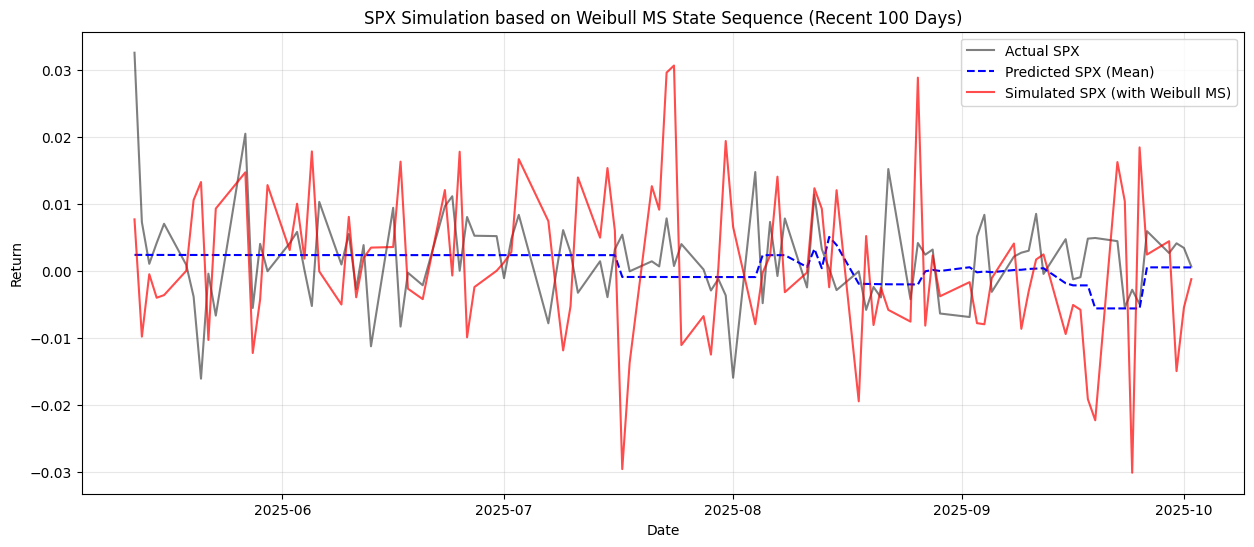

In [8]:
# レジームごとの共分散行列を計算
regime_cov_matrices = {}

for i in range(N_REGIMES):
    mask = df_features['Regime'] == i
    res_sp = df_features.loc[mask, 'resid_sp500'].values
    res_dgs = df_features.loc[mask, 'resid_dgs'].values
    
    # NaNを除外して計算
    valid_mask = ~np.isnan(res_sp) & ~np.isnan(res_dgs)
    if valid_mask.sum() > 1:
        cov_matrix = np.cov(res_sp[valid_mask], res_dgs[valid_mask])
        regime_cov_matrices[i] = cov_matrix
        print(f"\n【Regime {i} 共分散行列】")
        print(cov_matrix)
        # 相関係数も表示
        corr = cov_matrix[0, 1] / np.sqrt(cov_matrix[0, 0] * cov_matrix[1, 1])
        print(f"相関係数: {corr:.4f}")
    else:
        # データが足りない場合は単位行列を使用
        regime_cov_matrices[i] = np.eye(2) * 1e-6

# 最尤推定（MLE）で得られた Duration-Dependent パラメータを用いた状態系列の生成
n_steps = len(df_features)
simulated_regimes = np.zeros(n_steps, dtype=int)
simulated_regimes[0] = df_features['Regime'].iloc[0]

# 再現性のための乱数シード設定
np.random.seed(42)

duration = 1

for t in range(1, n_steps):
    prev_state = simulated_regimes[t-1]
    
    # 推定されたベース遷移確率を取得
    p_vector = transition_matrix[prev_state].copy()
    
    # 滞在期間に応じた自己遷移確率の減衰
    lam = decay_params[prev_state]
    if lam > 0:
        orig_p_ii = transition_matrix[prev_state, prev_state]
        # 推定された P_ii と lambda を用いて自己遷移確率を計算
        base_p_ii = fitted_p_ii[prev_state]
        new_p_ii = base_p_ii * np.exp(-lam * (duration - 1))
        
        # 確率の再配分（比例配分）
        p_vector[prev_state] = new_p_ii
        scale_factor = (1.0 - new_p_ii) / (1.0 - orig_p_ii) if (1.0 - orig_p_ii) > 0 else 0
        
        for idx in range(N_REGIMES):
            if idx != prev_state:
                p_vector[idx] = transition_matrix[prev_state, idx] * scale_factor
                
        # 再正規化
        p_vector = p_vector / np.sum(p_vector)
        
    next_state = np.random.choice(N_REGIMES, p=p_vector)
    simulated_regimes[t] = next_state
    
    if next_state == prev_state:
        duration += 1
    else:
        duration = 1

# 各レジームのVARMAXモデルの予測期待値をあらかじめ取得
regime_preds = {}
for i in range(N_REGIMES):
    if i in models_varmax:
        regime_preds[i] = models_varmax[i].predict()

# 生成された状態系列に基づくシミュレーションの実行
sp500_pred_sim = np.zeros(n_steps)
DGS10_pred_sim = np.zeros(n_steps)
shocks_sp = np.zeros(n_steps)
shocks_dgs = np.zeros(n_steps)

for t in range(n_steps):
    sim_regime = simulated_regimes[t]
    
    # シミュレーションされたレジームに対応する予測期待値を取得
    sp500_pred_sim[t] = regime_preds[sim_regime]['sp500'].iloc[t]
    DGS10_pred_sim[t] = regime_preds[sim_regime]['DGS10'].iloc[t]
    
    # シミュレーションされたレジームに対応する共分散行列からショックをサンプリング
    cov_matrix = regime_cov_matrices[sim_regime]
    shock = np.random.multivariate_normal([0, 0], cov_matrix)
    # 日次リターンの下限を -0.9 (-90%) にクリップして累積積でのつぶれを防ぐ
    shocks_sp[t] = shock[0]
    shocks_dgs[t] = shock[1]

# シミュレーション結果を上書き
df_features['Regime_simulated'] = simulated_regimes
df_features['sp500_pred'] = sp500_pred_sim
df_features['DGS10_pred'] = DGS10_pred_sim
df_features['sp500_simulated'] = np.clip(sp500_pred_sim + shocks_sp, -0.9, None)
df_features['DGS10_simulated'] = np.clip(DGS10_pred_sim + shocks_dgs, -0.9, None)

print("\nレジーム別の状態遷移確率行列を反映したシミュレーションデータを生成しました！")

round_cols = ['sp500_pred', 'sp500_simulated', 'DGS10_pred', 'DGS10_simulated']
df_features[round_cols] = df_features[round_cols].round(6)

output_df = df_features[['Regime', 'Regime_simulated', 'sp500', 'sp500_pred', 'sp500_simulated', 'DGS10', 'DGS10_pred', 'DGS10_simulated']]
print("【直近10日間の実際の値と予測値・シミュレーション値】")
display(output_df.tail(10))

# 実際の値と予測値・シミュレーション値のプロット
plt.figure(figsize=(15, 6))
plt.plot(output_df.index[-100:], output_df['sp500'][-100:], label='Actual SPX', color='black', alpha=0.5)
plt.plot(output_df.index[-100:], output_df['sp500_pred'][-100:], label='Predicted SPX (Mean)', color='blue', linestyle='--')
plt.plot(output_df.index[-100:], output_df['sp500_simulated'][-100:], label='Simulated SPX (with Markov chain)', color='red', alpha=0.7)
plt.title('SPX Simulation based on Markov Chain State Sequence (Recent 100 Days)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 6. 全期間での累積リターンの比較

初期値を $1$ として、実際のSPXリターンと、期待値のみを用いた予測リターン、ランダムショックを加えたシミュレーションリターンを累積（複利計算）して比較します。
※モデルが出力する期待値（`sp500_pred`）はボラティリティを持たないため、複利計算の仕様上（ボラティリティ・ドラッグの欠如により）非現実的な軌道を描いてしまう傾向がありますが、参考として表示しています。


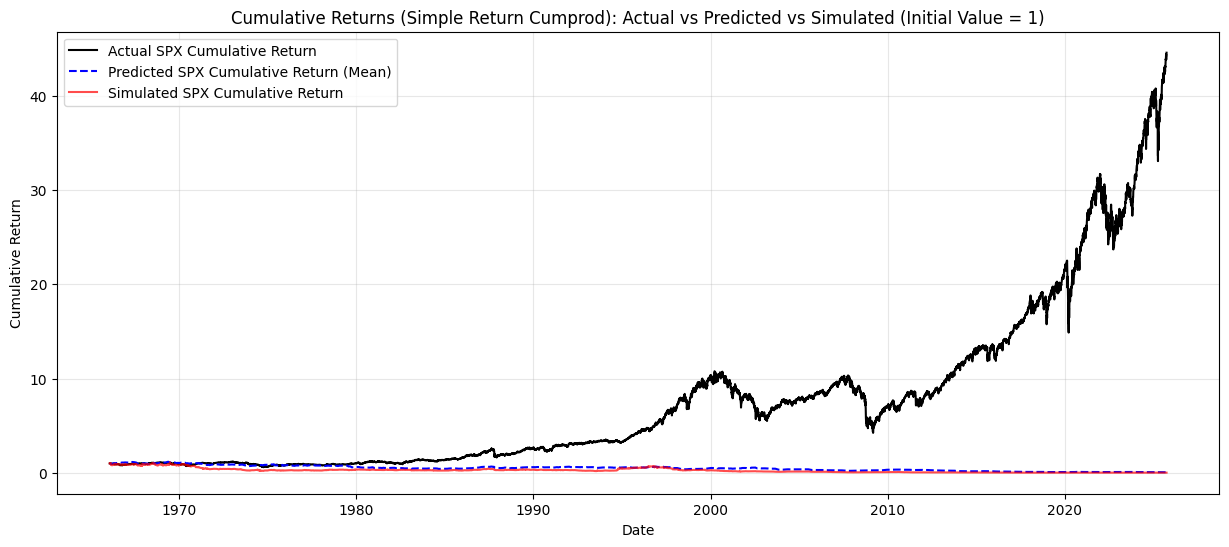

In [9]:
# 欠損値（NaN）を0で埋めてから累積積（cumprod）を計算
df_features['cum_sp500'] = (1 + df_features['sp500'].fillna(0)).cumprod()
df_features['cum_sp500_pred'] = (1 + df_features['sp500_pred'].fillna(0)).cumprod()
df_features['cum_sp500_sim'] = (1 + df_features['sp500_simulated'].fillna(0)).cumprod()

plt.figure(figsize=(15, 6))
plt.plot(df_features.index, df_features['cum_sp500'], label='Actual SPX Cumulative Return', color='black')
plt.plot(df_features.index, df_features['cum_sp500_pred'], label='Predicted SPX Cumulative Return (Mean)', color='blue', linestyle='--')
plt.plot(df_features.index, df_features['cum_sp500_sim'], label='Simulated SPX Cumulative Return', color='red', alpha=0.7)
plt.title('Cumulative Returns (Simple Return Cumprod): Actual vs Predicted vs Simulated (Initial Value = 1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 7. 実データとモデル生成データ（予測・シミュレーション）の相関比較

モデルが、S&P 500 と米国10年国債利回り (DGS10) の「2資産間の関係性（相関）」をどれだけ上手く再現できているかを検証します。
今回はレジームごとの固定相関を使用しているため、極端なスパイクのない安定した連動性がシミュレーションに反映されています。


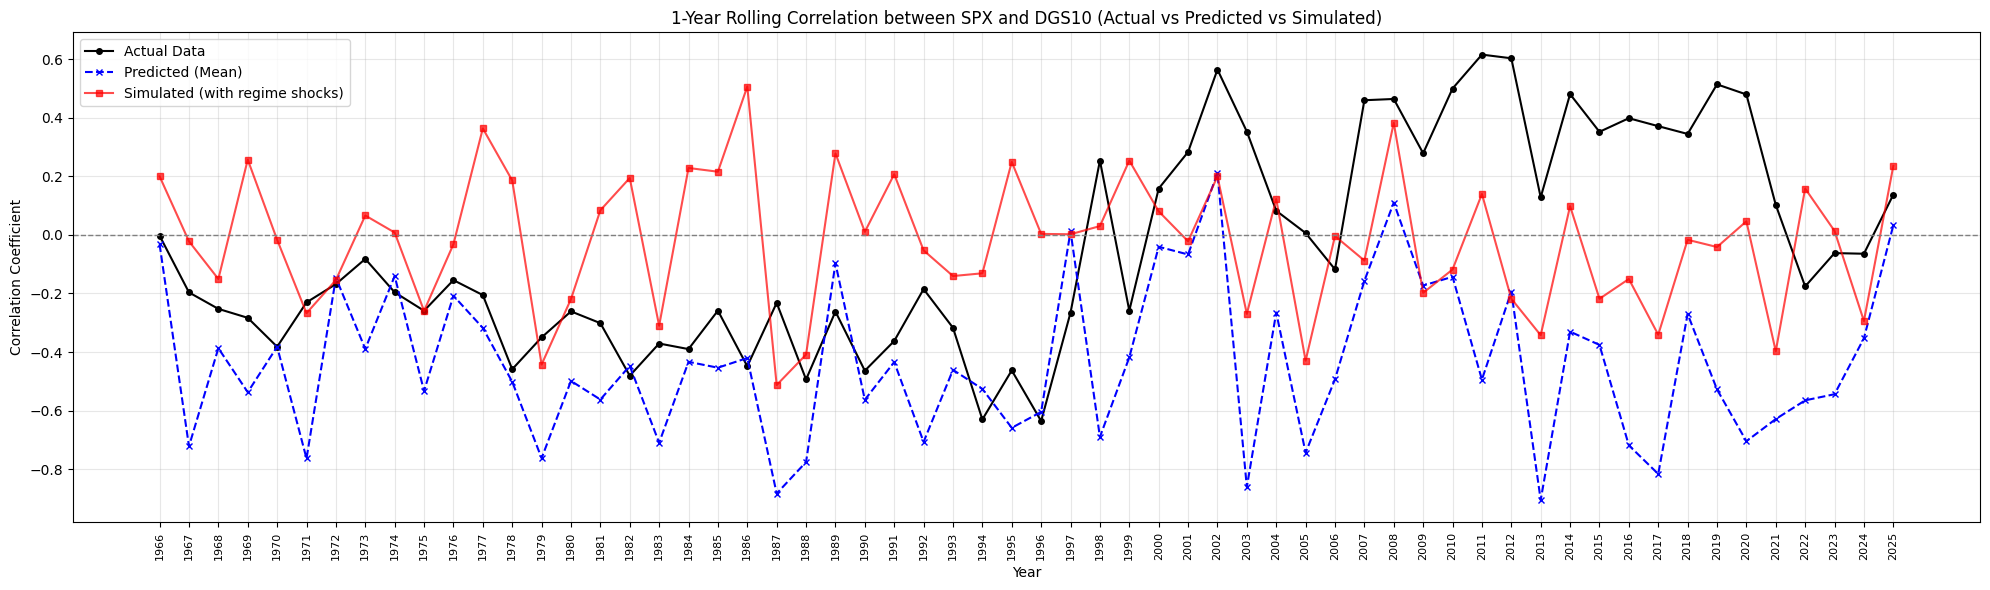


【相関係数のボラティリティ（標準偏差）の比較】


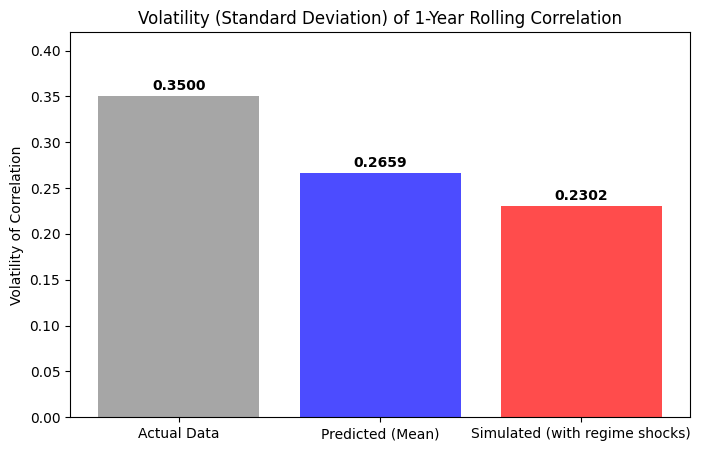

In [10]:
# 1年ごとのビンを作成
df_features['1Y_Label'] = df_features.index.year.astype(str)

# 1年ごとに相関を計算
corr_act = df_features.groupby('1Y_Label').apply(lambda g: g['sp500'].corr(g['DGS10']))
corr_pred = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_pred'].corr(g['DGS10_pred']))
corr_sim = df_features.groupby('1Y_Label').apply(lambda g: g['sp500_simulated'].corr(g['DGS10_simulated']))

corr_1y = pd.DataFrame({'Actual': corr_act, 'Predicted': corr_pred, 'Simulated': corr_sim})

# 折れ線グラフで視覚化
plt.figure(figsize=(20, 6))
plt.plot(corr_1y.index, corr_1y['Actual'], marker='o', label='Actual Data', color='black', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Predicted'], marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5, markersize=4)
plt.plot(corr_1y.index, corr_1y['Simulated'], marker='s', label='Simulated (with regime shocks)', color='red', alpha=0.7, linewidth=1.5, markersize=4)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.title('1-Year Rolling Correlation between SPX and DGS10 (Actual vs Predicted vs Simulated)')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 相関係数のボラティリティ比較
vol_act = corr_1y['Actual'].std()
vol_pred = corr_1y['Predicted'].std()
vol_sim = corr_1y['Simulated'].std()

print("\n【相関係数のボラティリティ（標準偏差）の比較】")

# ボラティリティを棒グラフで視覚化
plt.figure(figsize=(8, 5))
labels_vol = ['Actual Data', 'Predicted (Mean)', 'Simulated (with regime shocks)']
values_vol = [vol_act, vol_pred, vol_sim]
colors_vol = ['gray', 'blue', 'red']

plt.bar(labels_vol, values_vol, color=colors_vol, alpha=0.7)
plt.title('Volatility (Standard Deviation) of 1-Year Rolling Correlation')
plt.ylabel('Volatility of Correlation')
for i, v in enumerate(values_vol):
    if pd.notna(v):
        plt.text(i, v + (max([val for val in values_vol if pd.notna(val)] + [0])*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.ylim(0, max([val for val in values_vol if pd.notna(val)] + [0.1]) * 1.2)
plt.show()


## 8. 実データとモデル生成データの歪度・尖度の5年ごと比較

モデルが、S&P 500 と米国10年国債利回り (DGS10) の「歪度（Skewness：非対称性）」と「尖度（Kurtosis：テールの厚さ）」の動的な変化をどれだけ再現できているかを検証します。
歪度は分布の左右の非対称性を表し、尖度はテール（極端な値）の太さ（または中心への集中度）を表します。ここでは、統計的な信頼性を担保するため、5年ごとにデータを区切って評価します。

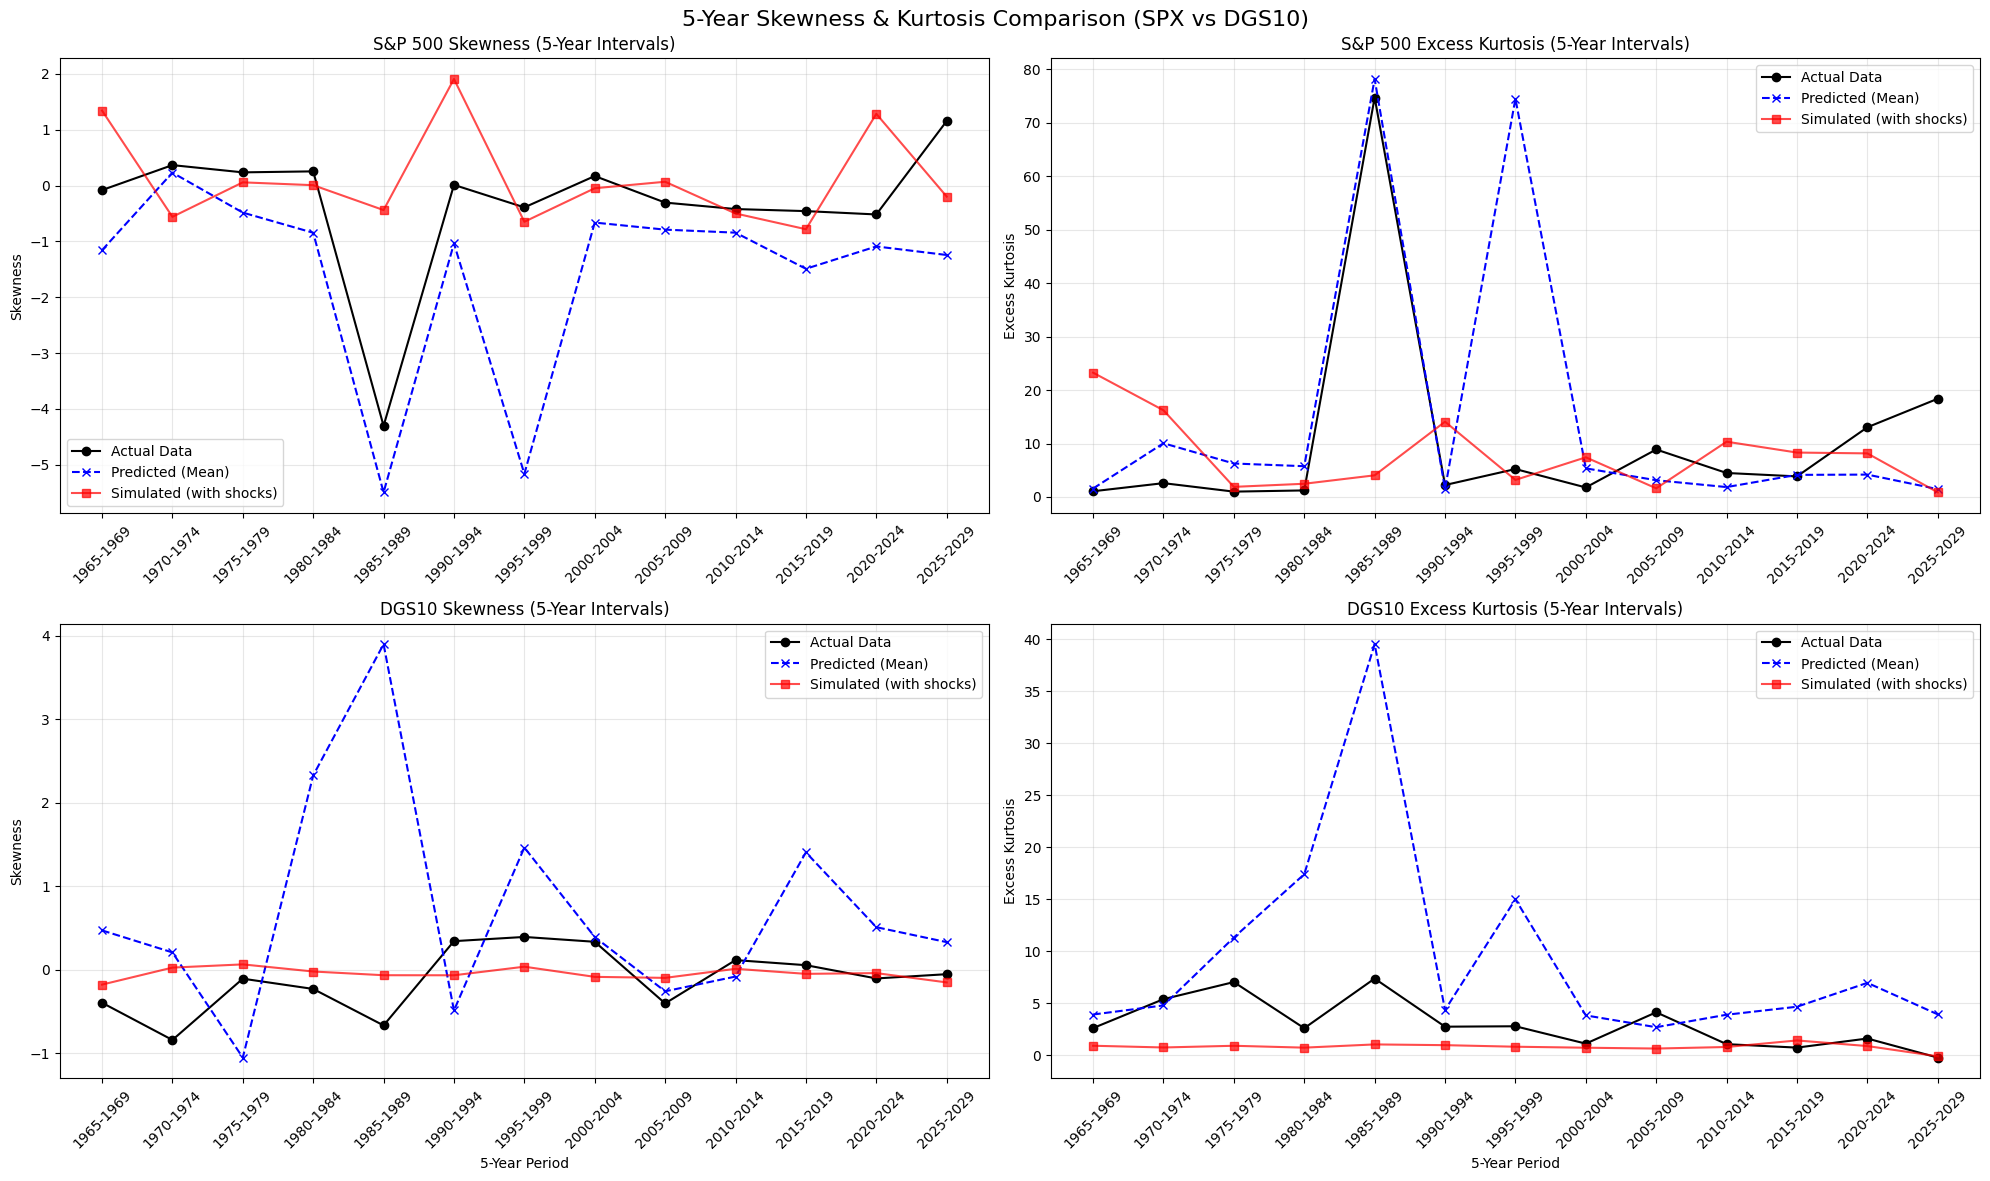

【実データとシミュレーションデータの統計量乖離 (MAE)】
S&P 500 - 歪度(Skewness) MAE: 0.9962
S&P 500 - 尖度(Kurtosis) MAE: 12.9381
DGS10   - 歪度(Skewness) MAE: 0.3021
DGS10   - 尖度(Kurtosis) MAE: 2.3172


In [11]:
# 5年ごとのラベルを作成（例: 1966-1970）
df_features['5Y_Label'] = (df_features.index.year // 5) * 5
df_features['5Y_Label'] = df_features['5Y_Label'].map(lambda y: f"{y}-{y+4}")

# S&P 500の歪度と尖度の計算
skew_act_sp500 = df_features.groupby('5Y_Label')['sp500'].skew()
skew_pred_sp500 = df_features.groupby('5Y_Label')['sp500_pred'].skew()
skew_sim_sp500 = df_features.groupby('5Y_Label')['sp500_simulated'].skew()

kurt_act_sp500 = df_features.groupby('5Y_Label')['sp500'].kurt()
kurt_pred_sp500 = df_features.groupby('5Y_Label')['sp500_pred'].kurt()
kurt_sim_sp500 = df_features.groupby('5Y_Label')['sp500_simulated'].kurt()

# DGS10の歪度と尖度の計算
skew_act_dgs10 = df_features.groupby('5Y_Label')['DGS10'].skew()
skew_pred_dgs10 = df_features.groupby('5Y_Label')['DGS10_pred'].skew()
skew_sim_dgs10 = df_features.groupby('5Y_Label')['DGS10_simulated'].skew()

kurt_act_dgs10 = df_features.groupby('5Y_Label')['DGS10'].kurt()
kurt_pred_dgs10 = df_features.groupby('5Y_Label')['DGS10_pred'].kurt()
kurt_sim_dgs10 = df_features.groupby('5Y_Label')['DGS10_simulated'].kurt()

# 5Y_Labelの順序を整える
labels_5y = sorted(df_features['5Y_Label'].unique())
skew_act_sp500 = skew_act_sp500.reindex(labels_5y)
skew_pred_sp500 = skew_pred_sp500.reindex(labels_5y)
skew_sim_sp500 = skew_sim_sp500.reindex(labels_5y)

kurt_act_sp500 = kurt_act_sp500.reindex(labels_5y)
kurt_pred_sp500 = kurt_pred_sp500.reindex(labels_5y)
kurt_sim_sp500 = kurt_sim_sp500.reindex(labels_5y)

skew_act_dgs10 = skew_act_dgs10.reindex(labels_5y)
skew_pred_dgs10 = skew_pred_dgs10.reindex(labels_5y)
skew_sim_dgs10 = skew_sim_dgs10.reindex(labels_5y)

kurt_act_dgs10 = kurt_act_dgs10.reindex(labels_5y)
kurt_pred_dgs10 = kurt_pred_dgs10.reindex(labels_5y)
kurt_sim_dgs10 = kurt_sim_dgs10.reindex(labels_5y)

# 2x2のグラフを描画
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# SPX Skewness
axes[0, 0].plot(labels_5y, skew_act_sp500, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[0, 0].plot(labels_5y, skew_pred_sp500, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[0, 0].plot(labels_5y, skew_sim_sp500, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[0, 0].set_title('S&P 500 Skewness (5-Year Intervals)')
axes[0, 0].set_ylabel('Skewness')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# SPX Kurtosis
axes[0, 1].plot(labels_5y, kurt_act_sp500, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[0, 1].plot(labels_5y, kurt_pred_sp500, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[0, 1].plot(labels_5y, kurt_sim_sp500, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[0, 1].set_title('S&P 500 Excess Kurtosis (5-Year Intervals)')
axes[0, 1].set_ylabel('Excess Kurtosis')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# DGS10 Skewness
axes[1, 0].plot(labels_5y, skew_act_dgs10, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[1, 0].plot(labels_5y, skew_pred_dgs10, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[1, 0].plot(labels_5y, skew_sim_dgs10, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[1, 0].set_title('DGS10 Skewness (5-Year Intervals)')
axes[1, 0].set_xlabel('5-Year Period')
axes[1, 0].set_ylabel('Skewness')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# DGS10 Kurtosis
axes[1, 1].plot(labels_5y, kurt_act_dgs10, marker='o', label='Actual Data', color='black', linewidth=1.5)
axes[1, 1].plot(labels_5y, kurt_pred_dgs10, marker='x', label='Predicted (Mean)', color='blue', linestyle='--', linewidth=1.5)
axes[1, 1].plot(labels_5y, kurt_sim_dgs10, marker='s', label='Simulated (with shocks)', color='red', alpha=0.7, linewidth=1.5)
axes[1, 1].set_title('DGS10 Excess Kurtosis (5-Year Intervals)')
axes[1, 1].set_xlabel('5-Year Period')
axes[1, 1].set_ylabel('Excess Kurtosis')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('5-Year Skewness & Kurtosis Comparison (SPX vs DGS10)', fontsize=16)
plt.tight_layout()
plt.show()

# 統計量の差分（平均絶対誤差: MAE）を計算して表示
mae_skew_sp500 = np.mean(np.abs(skew_act_sp500 - skew_sim_sp500))
mae_kurt_sp500 = np.mean(np.abs(kurt_act_sp500 - kurt_sim_sp500))
mae_skew_dgs10 = np.mean(np.abs(skew_act_dgs10 - skew_sim_dgs10))
mae_kurt_dgs10 = np.mean(np.abs(kurt_act_dgs10 - kurt_sim_dgs10))

print("【実データとシミュレーションデータの統計量乖離 (MAE)】")
print(f"S&P 500 - 歪度(Skewness) MAE: {mae_skew_sp500:.4f}")
print(f"S&P 500 - 尖度(Kurtosis) MAE: {mae_kurt_sp500:.4f}")
print(f"DGS10   - 歪度(Skewness) MAE: {mae_skew_dgs10:.4f}")
print(f"DGS10   - 尖度(Kurtosis) MAE: {mae_kurt_dgs10:.4f}")
